# Inference Examples

This notebook is intended to run inference on labelled data, that the model was not trained using. It does **not** mimic the true use-case of the model in running inference on new unlabelled data.

### Notebook Set-Up

In [10]:
import os

import torch
from torch.nn import functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from image_dataset import ImageDataset
from helper_functions import set_seed

In [2]:
# Specify GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

print(torch.cuda.get_device_name(0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Specify other environment variables
SEED = 666
set_seed(SEED)

NVIDIA GeForce RTX 4090
Using device: cuda


In [3]:
# Paths

repository_root = os.path.abspath('')
run_name = 'final_model'

weights_path = os.path.join(repository_root, run_name, 'weights.pth')
predictions_path = os.path.join(repository_root, run_name, 'predictions.pth')
metadata_path = os.path.join(repository_root, run_name, 'environment.pth')

images_directory = os.path.join(repository_root, 'Data_examples')

### DataLoader & Model Set-Up

In [4]:
# Load Class Map and Image Transforms

metadata = torch.load(metadata_path, weights_only = False)

class_map = metadata['class_map']
class_map_rev = {v: k for k, v in class_map.items()}

image_transforms = metadata['test_loader'].dataset.dataset.image_transforms

In [5]:
# Define Inference Dataset

ZOOPLANKTON_CLASSES = os.listdir(images_directory)
NUM_CLASSES = len(ZOOPLANKTON_CLASSES)

inference_class_indices = [class_map[cls_name] for cls_name in ZOOPLANKTON_CLASSES]

inference_dataset = ImageDataset(
    data_directory = images_directory,
    class_names = ZOOPLANKTON_CLASSES,
    class_ids = inference_class_indices,
    image_resolution = 64,
    image_transforms = image_transforms,
    seed = SEED
)

inference_dataset.append_image_transforms()

In [6]:
# Construct DataLoader
inference_indices = list(range(len(inference_dataset)))

inference_loader = DataLoader(
    dataset = Subset(inference_dataset, inference_indices),
    batch_size = 1,
    shuffle = False
)

In [7]:
# Load Model

model = models.densenet121(weights = None)
model.classifier = torch.nn.Linear(model.classifier.in_features, 14)

weights = torch.load(weights_path, map_location = device)

model.load_state_dict(weights)
model.to(device);

### Run Inference

In [8]:
# Inference

model.eval()
images, labels, probs, preds = [], [], [], []

with torch.no_grad():
    for image, label in inference_loader:
        image = image.to(device)
        label = label.to(device)
                
        output = model(image)
        prob = F.softmax(output, dim = 1)
        pred = output.argmax(dim = 1)

        images.append(image.cpu())
        labels.append(label)
        probs.append(prob)
        preds.append(pred)

images, labels, probs, preds = torch.cat(images), torch.cat(labels), torch.cat(probs), torch.cat(preds)


### Plot Results

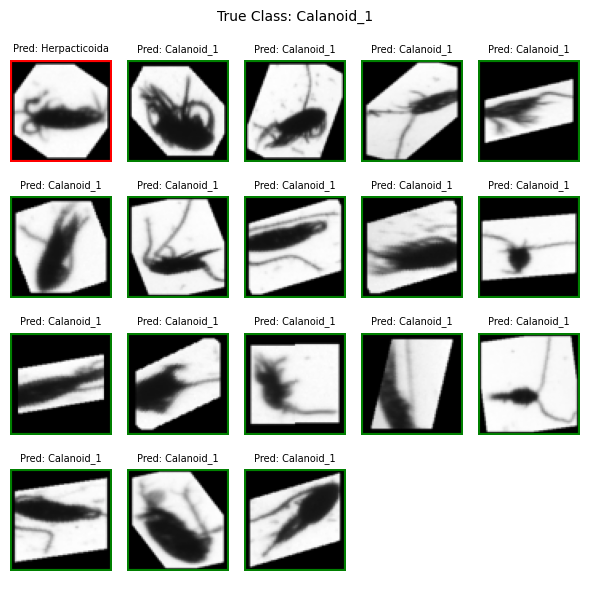

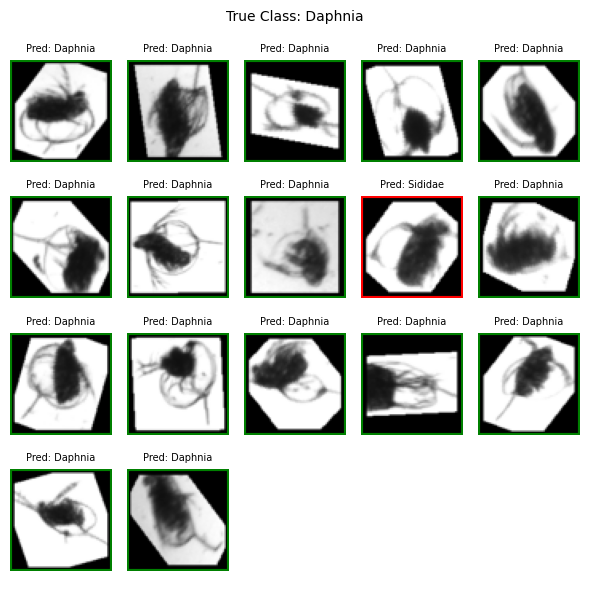

In [ ]:
max_images_per_row = 6
unique_classes = torch.unique(labels)

for cls_id in unique_classes:

    cls_ids = (labels == cls_id).nonzero(as_tuple = True)[0]
    
    # Set-up grid
    n_samples = len(cls_ids)
    n_cols = int(np.ceil(np.sqrt(n_samples)))
    n_rows = int(np.ceil(n_samples / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (6, 6))
    axes = axes.flatten() if n_samples > 1 else [axes]

    # Plot each image
    for ax, idx in zip(axes, cls_ids):
        image = images[idx].mean(0).numpy()
        label = labels[idx].item()
        pred = preds[idx].item()

        ax.imshow(image, cmap = 'gray')
        ax.set_title(f'Pred: {class_map_rev[pred]}', fontsize = 7)

        colour = 'green' if label == pred else 'red'
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform = ax.transAxes, linewidth = 3, edgecolor = colour, facecolor = 'none'
        )
        ax.add_patch(rect)
        ax.axis('off')

    # Set unused axes to blank
    for j in range(len(cls_ids), len(axes)):
        axes[j].axis('off')

    cls_name = class_map_rev[cls_id.item()]
    plt.suptitle(f'True Class: {cls_name}', fontsize = 10)
    plt.tight_layout()